# Predicción de diabetes


# Objetivo

El objetivo de este proyecto es el desarrollo de un modelo de aprendizaje automático supervisado (clasificación multiclase) para el diagnóstico del tipo de diabetes del usuario en base a datos clínicos y del estilo de vida.

Se pueden identificar estos tipos: No diabetes, Pre-diabetes, Tipo 1, Tipo 2 y Gestacional.  



# Colección de datos
Los datos provienen del dataset Diabetes Health Indicators https://www.kaggle.com/datasets/mohankrishnathalla/diabetes-health-indicators-dataset/data.

##Importación del dataset


In [ ]:
pip install catboost

In [ ]:
!pip install lightgbm

In [ ]:
#Importación de librerías

#manipulación de datos y df
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import joblib

#procesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

#evaluacion
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,f1_score, recall_score, roc_auc_score,precision_score, log_loss,RocCurveDisplay

#modelos
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb


In [ ]:
#Importación del csv
!wget https://raw.githubusercontent.com/Alferez36/Inteligencia-Artificial/refs/heads/main/diabetes_dataset.csv

--2026-01-31 18:09:38--  https://raw.githubusercontent.com/Alferez36/Inteligencia-Artificial/refs/heads/main/diabetes_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14365521 (14M) [text/plain]
Saving to: ‘diabetes_dataset.csv.1’

diabetes_dataset.cs 100%[===================>]  13.70M  --.-KB/s    in 0.1s    

2026-01-31 18:09:38 (107 MB/s) - ‘diabetes_dataset.csv.1’ saved [14365521/14365521]



In [ ]:
df = pd.read_csv('diabetes_dataset.csv')
df.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


División del dataset en training (80%) y testing (20%).

In [ ]:
X = df.drop(['diagnosed_diabetes', 'diabetes_stage'], axis=1)
y = df['diabetes_stage']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Análisis exploratorio de los datos (EDA)



## Introducción al dataset

In [ ]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [ ]:
total_pacientes = len(df)
print(f"Total de pacientes: {total_pacientes}")
gender_diff = df['diagnosed_diabetes'].value_counts(normalize="True").mul(100).round(4).astype(str) + ' %'
print(gender_diff)
stage = df['diabetes_stage'].value_counts(normalize="True").mul(100).round(4).astype(str) + ' %'
print(stage)

Total de pacientes: 100000
diagnosed_diabetes
1    59.998 %
0    40.002 %
Name: proportion, dtype: object
diabetes_stage
Type 2          59.774 %
Pre-Diabetes    31.845 %
No Diabetes      7.981 %
Gestational      0.278 %
Type 1           0.122 %
Name: proportion, dtype: object


Para la predicción binaria de la diabetes, el dataset está balanceado. Sin embargo, hay un **desbalance de clases** alto dentro del tipo con Gestacional y Tipo 1 ya que juntas no llegan al 0.5% de los casos.

Este desbalanceo de los datos tiene sentido dentro de la realidad. Más del 90% de los diabéticos padece de tipo 2.

https://idf.org/es/about-diabetes/diabetes-facts-figures/

## Limpieza y pre-procesamiento inicial de los datos

### Identificación de los valores nulos
No hay valores nulos, por lo que no faltan datos en la BBDD.

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
ethnicity,0
education_level,0
income_level,0
employment_status,0
smoking_status,0
alcohol_consumption_per_week,0
physical_activity_minutes_per_week,0
diet_score,0


Además, hay algunos valores en los que un 0 es físicamente imposible. Sin embargo, confirmamos que todas las columnas en las que hay 0, este valor puede tener sentido.

In [ ]:
(df == 0).sum()

,0
age,0
gender,0
ethnicity,0
education_level,0
income_level,0
employment_status,0
smoking_status,0
alcohol_consumption_per_week,13535
physical_activity_minutes_per_week,14
diet_score,46


### Identificación de los outliers
Hay algunos valores altos, pero tienen sentido dentro de una base de datos con pacientes diabéticos. Por ejemplo, un valor de 350 de triglicéridos es elevado, pero dentro de los valores posibles.

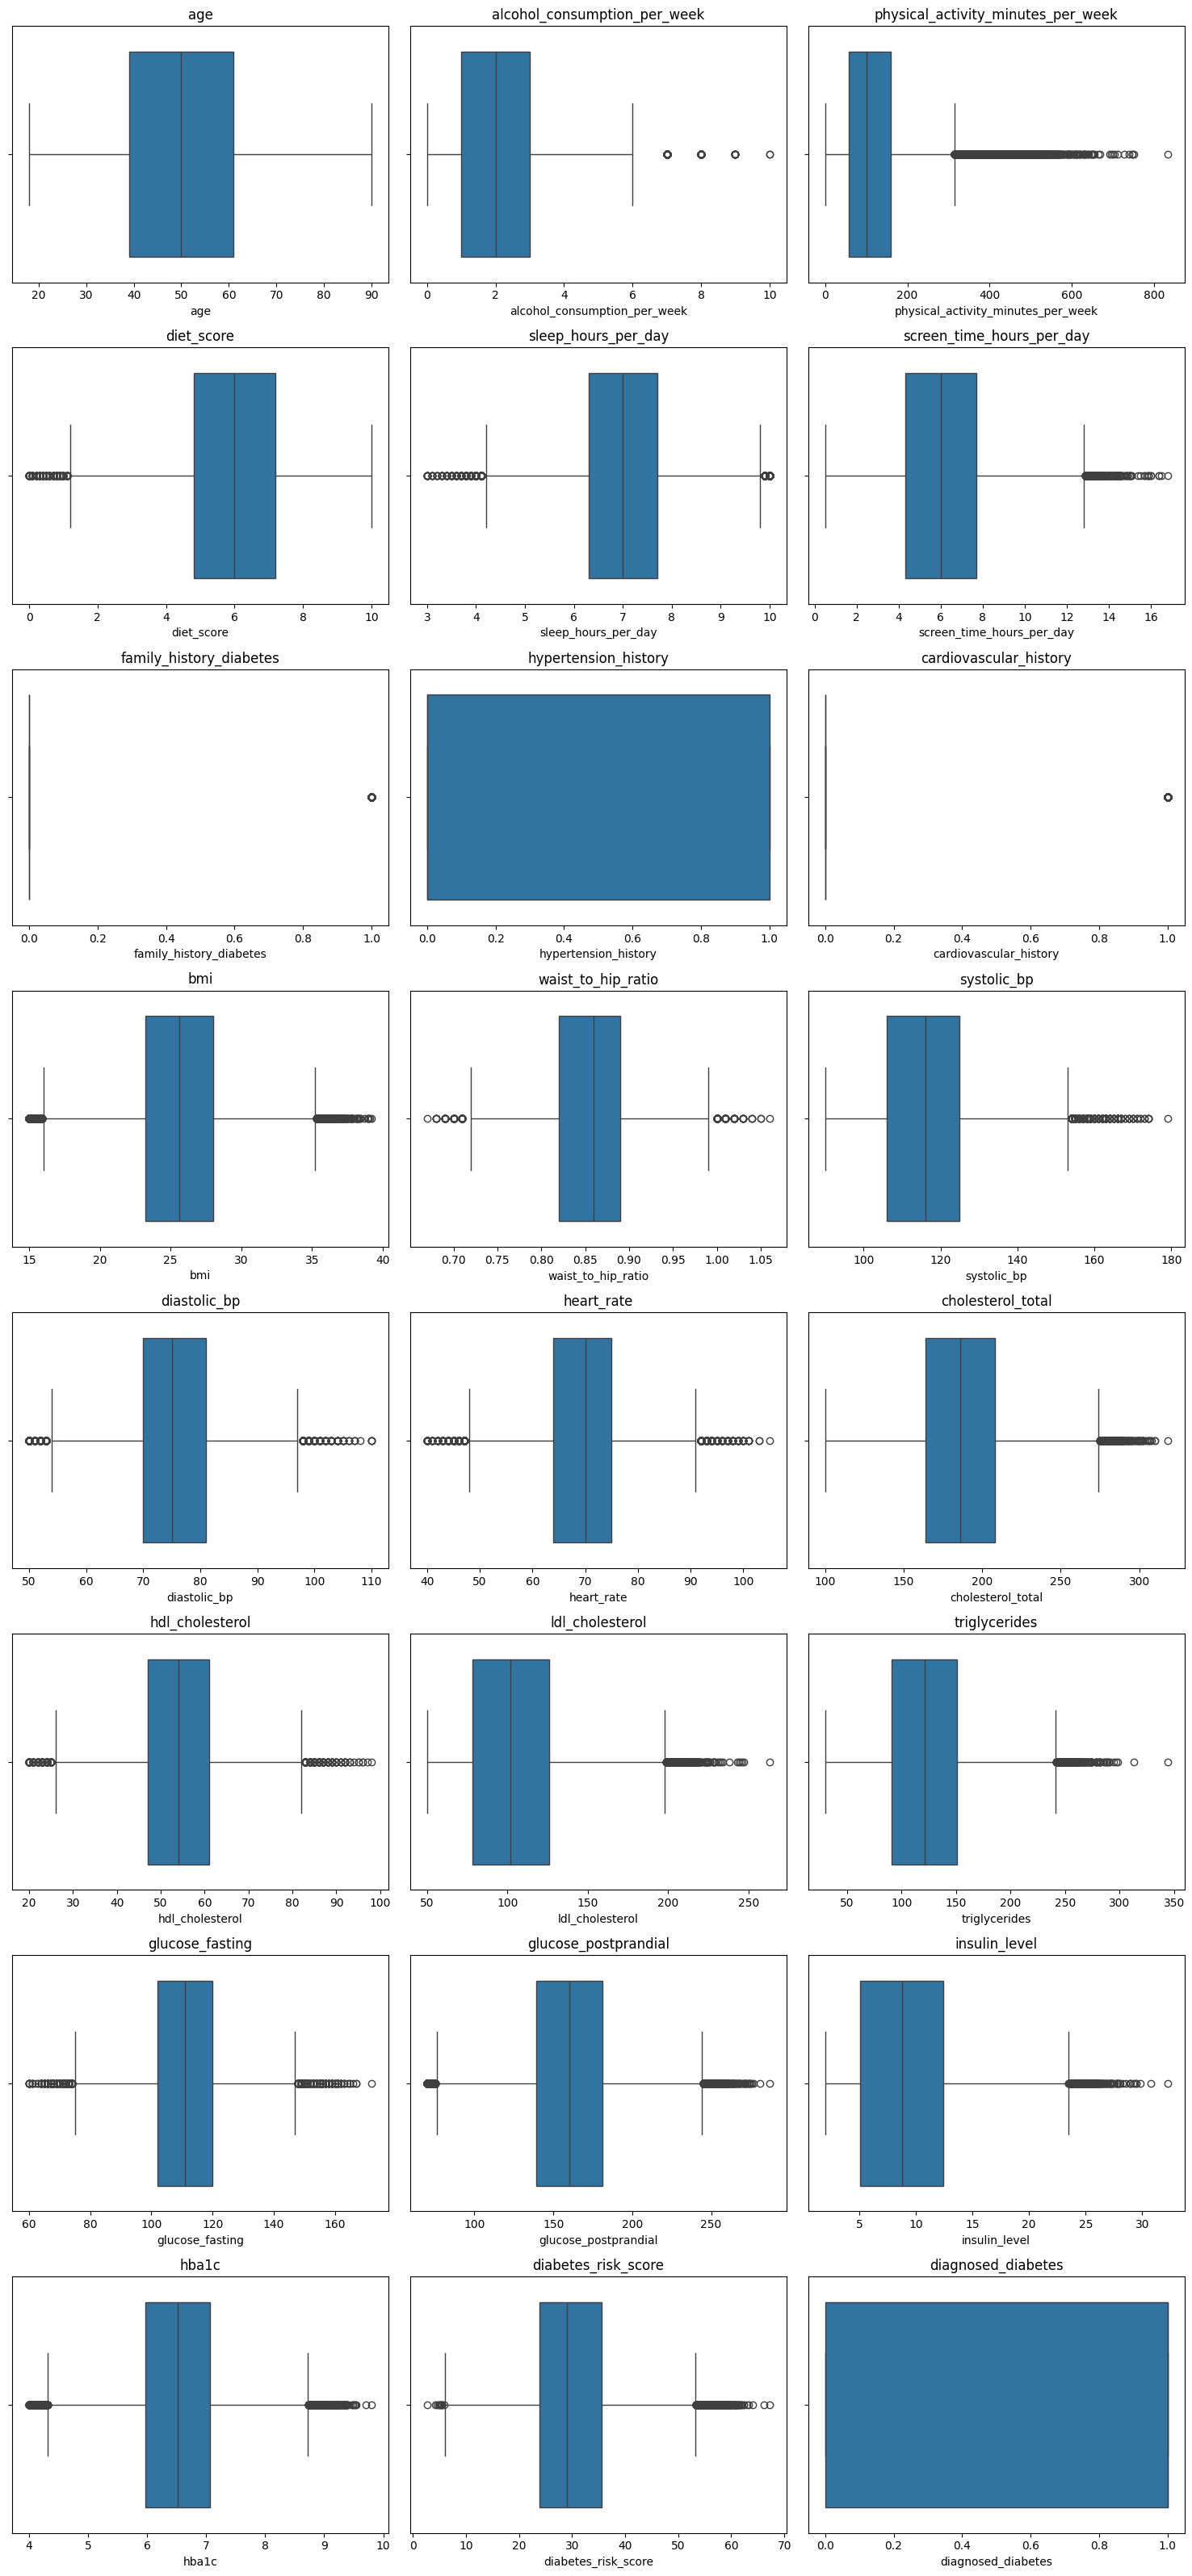

In [ ]:
#Boxplot para todas las columnas con valores numéricos
cols_numericas = df.select_dtypes(include=['number']).columns
n_filas = math.ceil(len(cols_numericas) / 3)

fig, axes = plt.subplots(n_filas, 3, figsize=(15,n_filas*4))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Comprobamos con una de las variables, como por ejemplo la edad, que los datos se encuentran dentro de los rangos usuales. En caso de que hubiera outliers, se podrían quitar las filas que contengan estos datos o seguir otra técnica. Por ejemplo, si se encuentran bastantes datos en la edad como "200" o "300", podría significar que se ha añadido un 0 y debería ser "20" o "30".

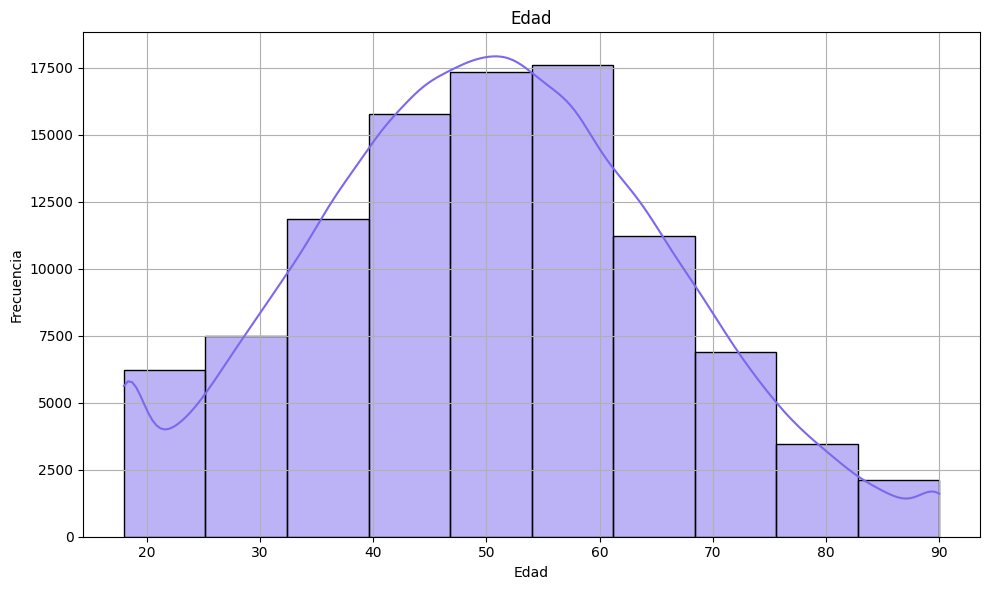

In [ ]:
plt.figure(figsize = (10,6))
sns.histplot(df["age"], bins=10, kde=True,
color='mediumslateblue')
plt.title("Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.tight_layout()
plt.show()

## Factores de riesgo
Dentro de esta base de datos se tienen en cuenta tres glucosas:
* hba1 (hemoglobina glicosilada o glicada): mide el nivel promedio de glucosa durante los últimos tres meses.
* glucose_fasting (basal): nivel de glucosa después de un periodo de ayuno.
* glucose_postpandrial (postpandrial): nivel de glucosa tras las comidas.

Estas son las medidas que más importancia tienen para un diagnóstico clínico. En los siguientes gráficos se comprueba esta correlación.  

Antes compruebo que los valores relacionados con el estilo de vida apenas tienen relación (valores cercanos a 0 o negativos).

<Axes: >

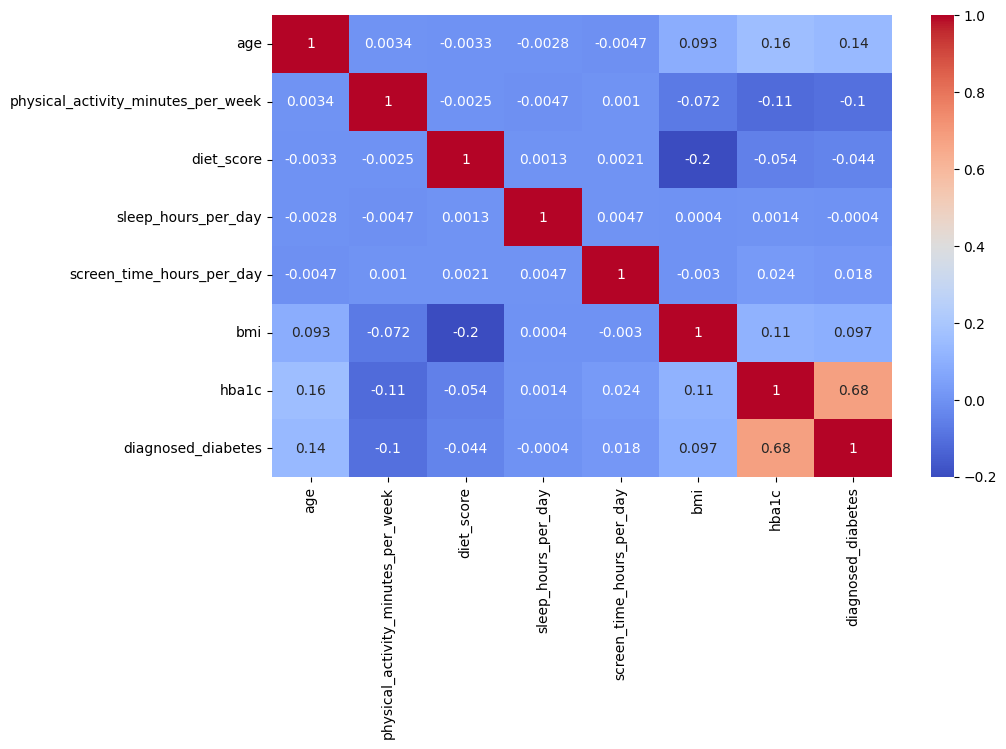

In [ ]:
estilo = ['age', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'hba1c','diagnosed_diabetes']

plt.figure(figsize=(10, 6))
sns.heatmap(df[estilo].corr(), annot=True, cmap='coolwarm')

<Axes: >

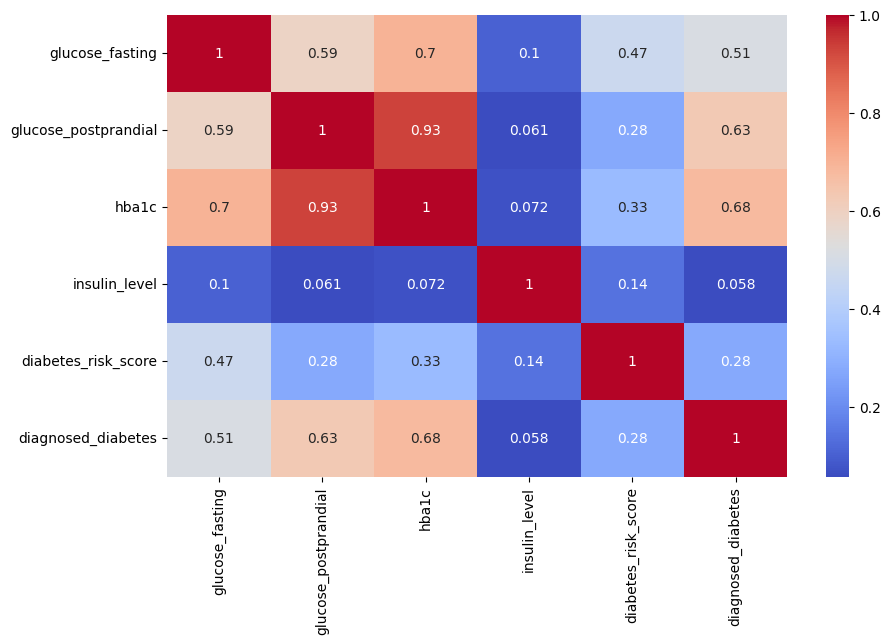

In [ ]:
glucemia = ['glucose_fasting', 'glucose_postprandial', 'hba1c', 'insulin_level', 'diabetes_risk_score', 'diagnosed_diabetes']

plt.figure(figsize=(10, 6))
sns.heatmap(df[glucemia].corr(), annot=True, cmap='coolwarm')

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


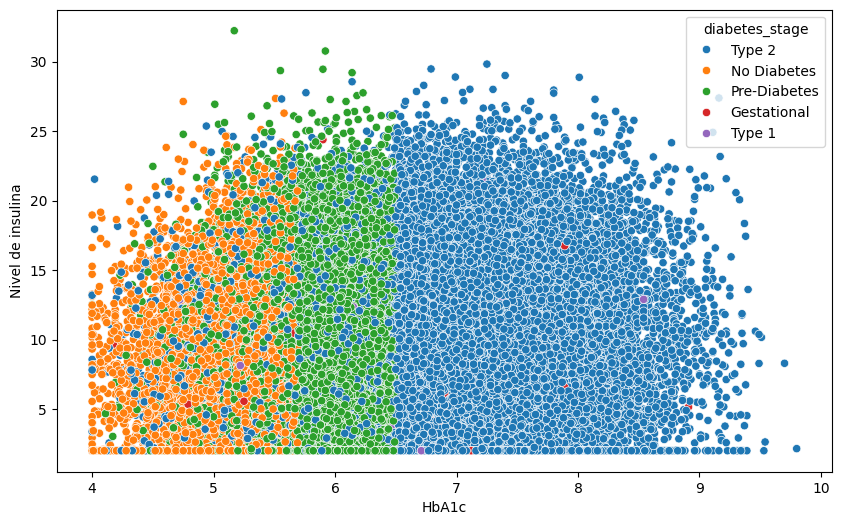

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='hba1c',y='insulin_level',hue='diabetes_stage')
plt.xlabel('HbA1c')
plt.ylabel('Nivel de insulina')
plt.show()

Hay una diferenciación clara de los datos de la aglicada entre los distintos tipos. Sin embargo, apenas se ven puntos de tipo 1 (morado) y gestacional (rojo) por el desbalanceo entre las clases.

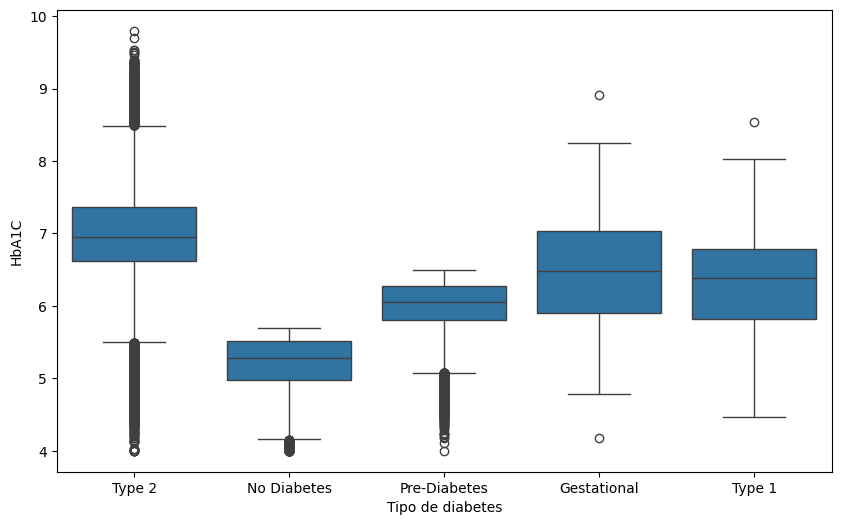

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='diabetes_stage',y='hba1c')
plt.xlabel('Tipo de diabetes')
plt.ylabel('HbA1C')
plt.show()

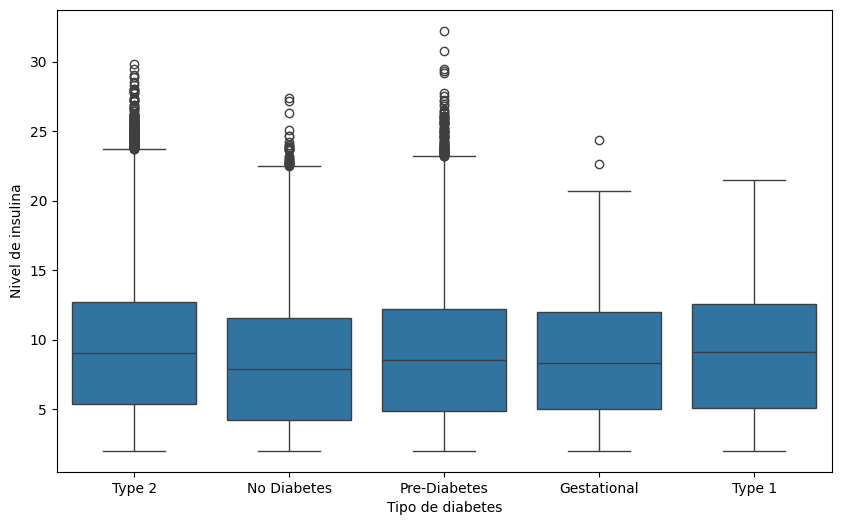

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='diabetes_stage',y='insulin_level')
plt.xlabel('Tipo de diabetes')
plt.ylabel('Nivel de insulina')
plt.show()

Los niveles de insulina no varían entre los diferentes tipos de diabetes, pero la hemoglobina glicada (HbA1c) sí que depende altamente del tipo. Esto se puede confirmar en los gráficos posteriores.

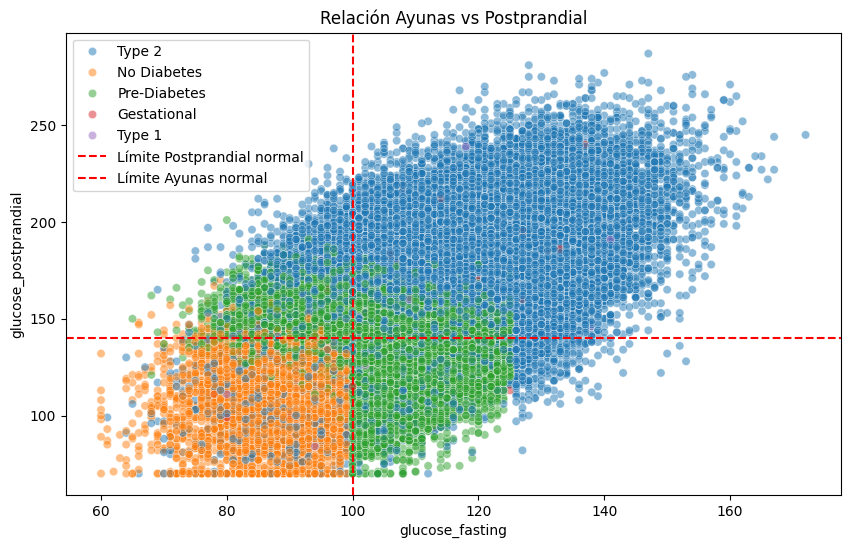

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='glucose_fasting', y='glucose_postprandial', hue='diabetes_stage', alpha=0.5)
plt.title('Relación Ayunas vs Postprandial')
plt.axhline(140, color='red', linestyle='--', label='Límite Postprandial normal')
plt.axvline(100, color='red', linestyle='--', label='Límite Ayunas normal')
plt.legend()
plt.show()

La gran parte del tipo 2 se concentra en el cuadrante negativo para ambas glucosas, la prediabentes en el centro y los no diabéticos en ambos cuadrados positivos. El resto de los tipos tiene pocos datos.

La edad también puede ser un factor determinante.

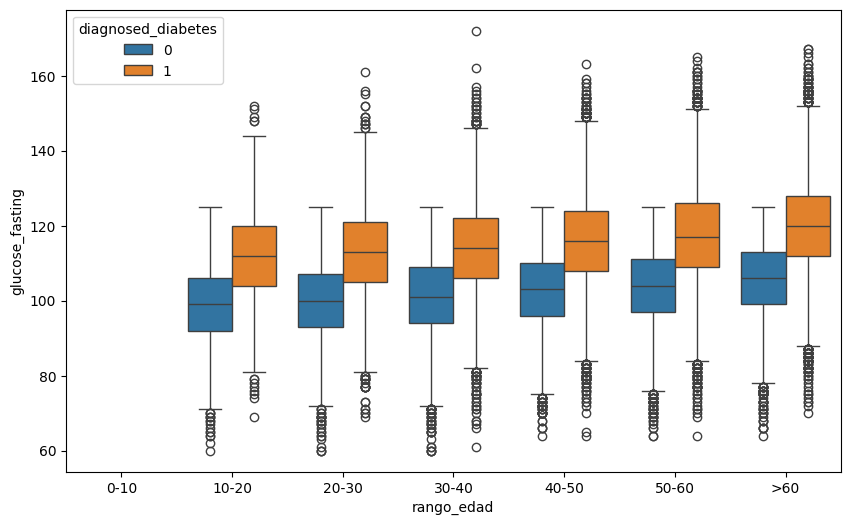

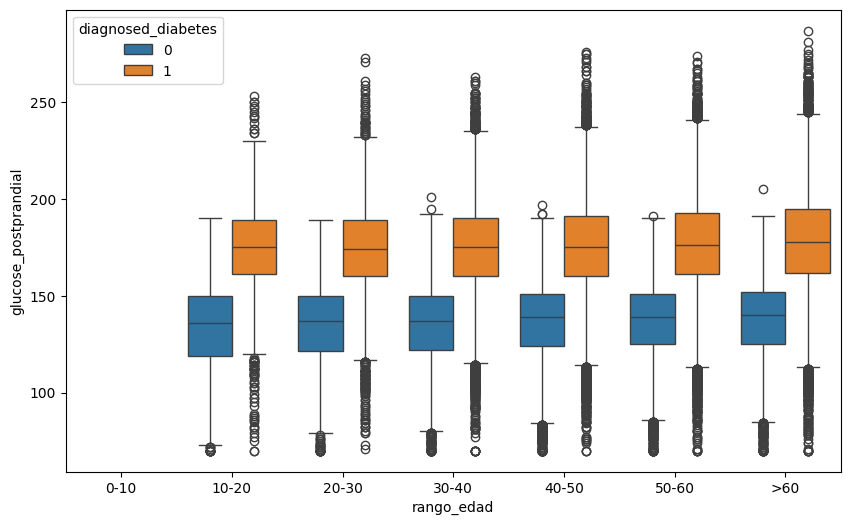

In [ ]:
df['rango_edad'] = pd.cut(df['age'], bins=[0,10,20,30,40,50,60,100], labels=['0-10','10-20','20-30','30-40','40-50','50-60','>60'])

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='rango_edad', y='glucose_fasting', hue='diagnosed_diabetes')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='rango_edad', y='glucose_postprandial', hue='diagnosed_diabetes')
plt.show()

**Glucemia basal (en ayunas)**  

Tanto en diabéticos como no diabéticos, la mediana de la glucosa en ayunas sube con la edad.


  
**Glucemia Postprandial**  

La mediana de glucosa se mantiene más constante con el paso de los años que en la glucemia en ayunas. Sin embargo, se ve una mayor diferencia entre los niveles de glucosa entre los diabéticos y no diabéticos en cualquier generación.


Por tanto, para ambas glucosas, aumenta ligeramente con la edad, mayormente la basal. Sin embargo, se confirma que los diabéticos gestionan peor la glucosa tras las comidas.



# Codificación

Algunos de los algortimos que vamos a utilizar no admiten texto. Para las categorías nominales (sin orden intrínseco de importancia) aplicaremos One-Hot encoding (codificación en caliente) y para las categorías ordinales, codificación ordinal.

Para los modelos no basados en árboles es importante que todas las características estén en la misma escala. Para esto se ha utilizado StandardScaler. Es importante remarcar que únicamente se ha realizado este proceso a las categorías numéricas.

Los modelos basados en árboles no necesitan de escalado. Sin embargo, hemos aplicado el mismo pipeline para mantener una coherencia metedeológica en los tres.

In [ ]:
#División según tipo de variable
# Numéricas
cols_num = [
    'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week',
    'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
    'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
    'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides',
    'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c',
    'diabetes_risk_score'
]

# Nominales (sin orden)
cols_cat= [
    'gender', 'ethnicity', 'employment_status'
]

# Ordinales (con orden)
cols_ordinal = [
    'education_level', 'income_level', 'smoking_status'
]

education_order = ['No formal', 'Highschool', 'Graduate', 'Postgraduate']
income_order = ['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']
smoking_order = ['Never', 'Former', 'Current']
diabetes_stage = ['No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2', 'Gestational']

#Binarias
cols_bin = [
    'family_history_diabetes', 'hypertension_history',
    'cardiovascular_history'
]

#Otra
id_col = ['patient_id']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), cols_num),
        ('cat', OneHotEncoder(drop='first'), cols_cat),
        ('ord', OrdinalEncoder(categories=[
            education_order,
            income_order,
            smoking_order,
        ]), cols_ordinal),
        ('bin', 'passthrough', cols_bin)
    ]
)

pipeline_preprocess = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

In [ ]:
pipeline_preprocess.fit(X_train) #solo para el entrenamiento para evitar fuga de datos

X_train_p = pipeline_preprocess.transform(X_train)
X_test_p = pipeline_preprocess.transform(X_test)

diabetes_stage es la variable objetivo (y), por lo que no se pasa por el preprocesador de Características para evitar la fuga de datos. Para poder entrenar los modelos, se debe hacer un mapping para el estado de la diabetes. Esto significa que se deben de pasar el texto a números (por ejemplo, Diabetes Tipo 1 a 1).

In [ ]:
label_mapping = {val: i for i, val in enumerate(diabetes_stage)}
y_train_encoded = y_train.map(label_mapping)
y_test_encoded = y_test.map(label_mapping)

# Entrenamiento de Modelos

Se implementan tres algoritmos de Gradient Boosting (LightGBM, XGBoost y CatBoost) con validación cruzada (Stratified K-Fold).

In [ ]:
#transformar a dataframe para mantener el nombre de las columnas
feature_names = pipeline_preprocess.named_steps['preprocessor'].get_feature_names_out()
X_train_cv = pd.DataFrame(X_train_p, columns=feature_names)
X_test_cv = pd.DataFrame(X_test_p, columns=feature_names)
y_train_cv = y_train_encoded.values

n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

n_classes = len(np.unique(y_train_cv)) #número de clases

#array probabilidades
oof_lgb = np.zeros((len(X_train_cv), n_classes))
oof_xgb = np.zeros((len(X_train_cv), n_classes))
oof_cat = np.zeros((len(X_train_cv), n_classes))
pred_lgb = np.zeros((len(X_test_cv), n_classes))
pred_xgb = np.zeros((len(X_test_cv), n_classes))
pred_cat = np.zeros((len(X_test_cv), n_classes))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_cv, y_train_cv)):
    X_tr, X_val = X_train_cv.iloc[train_idx], X_train_cv.iloc[val_idx]
    y_tr, y_val = y_train_cv[train_idx], y_train_cv[val_idx]

    # XGBoost
    m_xgb = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                          objective='multi:softprob', num_class=n_classes, eval_metric='mlogloss', random_state=42)
    m_xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = m_xgb.predict_proba(X_val)
    pred_xgb += m_xgb.predict_proba(X_test_cv) / n_splits

    # LightGBM
    m_lgb = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, objective='multiclass', num_class=n_classes, random_state=42, verbose=-1)
    m_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(25)])
    oof_lgb[val_idx] = m_lgb.predict_proba(X_val)
    pred_lgb += m_lgb.predict_proba(X_test_cv)/ n_splits

    #CatBoost
    m_cat = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6, loss_function='MultiClass',
                               random_state=42, verbose=0, early_stopping_rounds=25)
    m_cat.fit(X_tr, y_tr, eval_set=(X_val, y_val))
    oof_cat[val_idx] = m_cat.predict_proba(X_val)
    pred_cat += m_cat.predict_proba(X_test_cv) / n_splits

    print(f"Fold {fold+1} completado.")

Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[92]	valid_0's multi_logloss: 0.243029
Fold 1 completado.
Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[88]	valid_0's multi_logloss: 0.24306
Fold 2 completado.
Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[95]	valid_0's multi_logloss: 0.246834
Fold 3 completado.
Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[88]	valid_0's multi_logloss: 0.236351
Fold 4 completado.
Training until validation scores don't improve for 25 rounds
Early stopping, best iteration is:
[95]	valid_0's multi_logloss: 0.232588
Fold 5 completado.


El modelo se paró alrededor de la iteración 90 aunque estuviera configurado para 500 para evitar el overfitting.



Debido a la desbalance de clases es importante utilizar:

```
# class_weight='balanced'
```
Fuerza al modelo a prestar atención a las clases minoritarias a costa de bajar la precisión en las mayoritarias. Sin embargo, debido alto desbalance, he decidido seguir esta línea de trabajo.


Guardamos las predicciones OOF (Out-Of-Fold) predicion para entrenar el **LogisticRegression** como un meta-modelo que aprenda de estas predicciones.

In [ ]:
X_meta_train = np.hstack([oof_lgb, oof_xgb, oof_cat])

X_meta_test = np.hstack([pred_lgb, pred_xgb, pred_cat])

meta_model = LogisticRegression(multi_class='multinomial', max_iter=1000, class_weight='balanced')
meta_model.fit(X_meta_train, y_train_cv)

final_preds_proba = meta_model.predict_proba(X_meta_test)
final_preds_class = meta_model.predict(X_meta_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# Técnicas de prevención del sobreajuste
Los modelos elegidos incluyen intrínsicamente técnicas de regularización y podas. Además, se utilizan parámetros como n_estimators y max_depth para controlar los parámetros.

# Pruebas y evaluación del modelo

Al ser el objetivo de este prototipo del diagnóstico de una enfermedad, es más importante disminuir el número de falsos negativos que positivos. Por lo tanto, hay que prestar atención a la métrica del recall, que mide la capacidad de encontrar las muestras positivas.

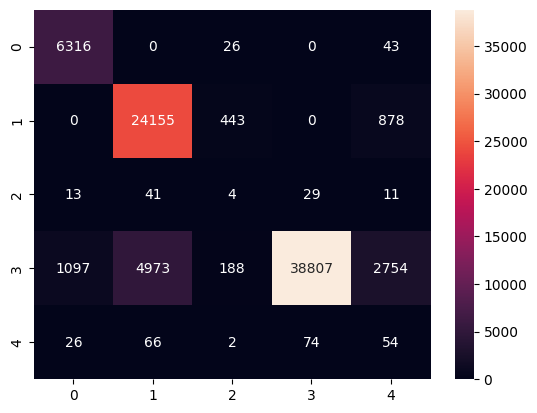

In [ ]:
sns.heatmap(confusion_matrix(y_train_cv, meta_model.predict(X_meta_train)), annot=True, fmt='d')
plt.show()

El sesgo del modelo se ve en la diagonal principal, en la que se ven los aciertos de cada clase. La clase 3 y la clase 1 tienen muy buen desempeño, pero en la clase 2 y 4 apenas tiene aciertos. La mayoría de los errores en las clases minoritarias se clasificaron como Clase 1 o Clase 3.  

In [ ]:
# Generamos el reporte de clasificación
report = classification_report(y_train_cv, meta_model.predict(X_meta_train))

print("Reporte de clasificación")
print(report)

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.85      0.99      0.91      6385
           1       0.83      0.95      0.88     25476
           2       0.01      0.04      0.01        98
           3       1.00      0.81      0.89     47819
           4       0.01      0.24      0.03       222

    accuracy                           0.87     80000
   macro avg       0.54      0.61      0.55     80000
weighted avg       0.93      0.87      0.89     80000



El accuracy es del 87% es debido a las clases mayoritarias (que tienen una precisión y recall perfecta o casi perfecta), pero no significa que sea un buen modelo. El Macro Avg promedia a las clases sin importar el número de datos y es de 0.54. Además, la clase 2 y 4 tienen un casi nulo f1 o precisión, respectivamente.

In [ ]:
def matriz(y_true, y_pred, labels_names):
    matrix = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, annot=True, fmt='.2%', cmap='Greens', xticklabels=labels_names, yticklabels=labels_names)
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.show()

def metricas(nombre, y_true, y_pred):
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (C1)': precision_score(y_true, y_pred, average='weighted'),
        'Recall (C1)': recall_score(y_true, y_pred, average='weighted'),
        'F1-Score (C1)': f1_score(y_true, y_pred, average='weighted')
    }

In [ ]:
print("\nResultados (AUC ROC):")
print(f"XGBoost AUC: {roc_auc_score(y_train_cv, oof_xgb,multi_class='ovr'):.4f}")
print(f"LightGBM AUC: {roc_auc_score(y_train_cv, oof_lgb,multi_class='ovr'):.4f}")
print(f"CatBoost AUC: {roc_auc_score(y_train_cv, oof_cat,multi_class='ovr'):.4f}")

#One-vs-Rest (ovr): campara cada clase contra el resto

final_oof = (oof_xgb + oof_lgb + oof_cat) / 3
print(f"AUC: {roc_auc_score(y_train_cv, final_oof,multi_class='ovr'):.4f}")


Resultados (AUC ROC):
XGBoost AUC: 0.9353
LightGBM AUC: 0.9357
CatBoost AUC: 0.9231
AUC: 0.9332


A primera vista los resultados del área bajo la curva ROC son excelentes, mayores a 0.9. Sin embargo, esto es debido a que el modelo es capaz de distinguir con gran claridad las clases mayoritarias, es decir, la mayor parte de los datos.

/tmp/ipython-input-2523646324.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')


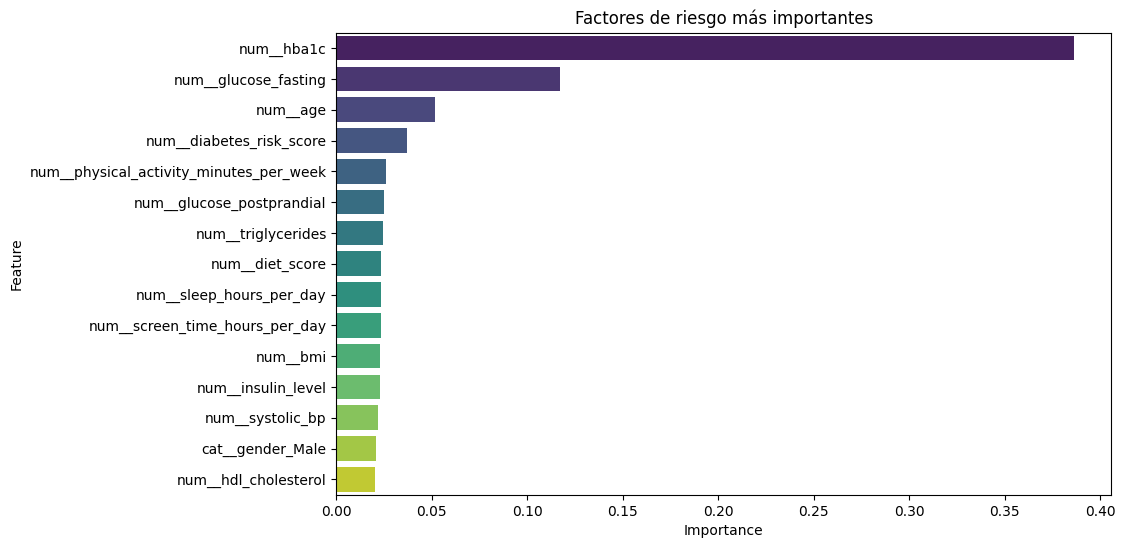

In [ ]:
feature_names = pipeline_preprocess.named_steps['preprocessor'].get_feature_names_out()

feat_imp_xgb = m_xgb.feature_importances_ / m_xgb.feature_importances_.sum()
feat_imp_lgb = m_lgb.feature_importances_ / m_lgb.feature_importances_.sum()
feat_imp_cat = m_cat.get_feature_importance() / m_cat.get_feature_importance().sum()

final_importance = (feat_imp_xgb + feat_imp_lgb + feat_imp_cat) / 3

df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': final_importance})
df_imp = df_imp.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_imp, palette='viridis')
plt.title('Factores de riesgo más importantes')
plt.show()

Tal y como se planteó en el EDA, la glucosa glicada y basal plantean, son las más importantes, seguida por la edad.  

Dados estos datos, el modelo recae bastante en la aglicada, casi como una regla que se aprende. Para un futuro proyecto, sería interesante ver como se comporta el modelo sin recaer en este dato.

# Posible despliegue del modelo en ambientes de uso real

Se exportan los modelos en un archivo .joblib para un posible despliegue del modelo en una aplicación web. Se podría desarrollar con la librería de streamlit y desplegarlo para tener acceso a través de un enlace además de manera local.

In [ ]:
joblib.dump(m_xgb, 'xgb_model.joblib')
joblib.dump(m_lgb, 'lgb_model.joblib')
joblib.dump(m_cat, 'cat_model.joblib')
joblib.dump(pipeline_preprocess, 'preprocessor.joblib')

['preprocessor.joblib']

Esta podría de utilidad para los profesionales de la salud que no tienen capacidad de diagnóstico clínico de la diabetes, como por ejemplo los nutricionistas. Les sería útil una herramienta de confirmación que añadir al historial del paciente.

Otro uso sería un diagnóstico de gran cantidad de datos. Sin embargo, a nivel individual un médico no necesita una herramienta teniendo los datos de las glucosas y el risk score. Además, es poco útil si estos datos no están disponibles de antemano. Por lo tanto, sugiero como futuro trabajo el entrenamiento de un modelo sin estos datos como un predicción de diabetes temprana. Además, como vimos en el EDA, es posible que el modelo recaiga demasiado en estos datos y haya aprendido. Sería interesante ver en qué features recae el modelo cuando no puede utilizar su regla aprendida. Otro posible trabajo sería incluir métodos como SMOTE para mejorar el desbalance de clases (creación de datos sintéticos sobre las clases minoritarias).